#**Modelo Predictivo - AVISTAMIENTOS DE AVES**


---





# Carga del dataset final

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os, unicodedata
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Montar Google Drive para acceder al archivo
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Ruta del archivo en Google Drive
# Asegúrate de que la ruta sea correcta.
DATA_DIR = '/content/drive/MyDrive/Proyectos/Aves'

PATH_INPUT = f'{DATA_DIR}/dataset-2025-definitivo.csv'

# Cargar el archivo CSV en un DataFrame de pandas
try:
    df = pd.read_csv(PATH_INPUT, sep=',', engine='python')
    df_copy = df.copy(deep=True)
    print("Archivo cargado exitosamente.")
    print(df.info())
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {PATH_INPUT}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Mounted at /content/drive
Archivo cargado exitosamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79215 entries, 0 to 79214
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order                          79215 non-null  object 
 1   family                         79215 non-null  object 
 2   genus                          79215 non-null  object 
 3   species                        79215 non-null  object 
 4   individualCount                79215 non-null  int64  
 5   decimalLatitude                79215 non-null  float64
 6   decimalLongitude               79215 non-null  float64
 7   coordinateUncertaintyInMeters  79215 non-null  float64
 8   day                            79215 non-null  int64  
 9   month                          79215 non-null  int64  
 10  timeRange                      79215 non-null  int64  
 11  hour                           79215 non-null  flo

In [26]:
df = df_copy.copy(deep=True)

In [27]:
# Reemplazar SPECIES por GENUS
class_counts = df['species'].value_counts()
print(class_counts)

rare_classes = class_counts[class_counts <= 500].index.tolist()
print("Clases raras:", rare_classes)
print("Cantidad de clases raras:", len(rare_classes))

df.loc[df['species'].isin(rare_classes), 'species'] = df['genus']

# Reemplazar SPECIES por FAMILY
class_counts = df['species'].value_counts()
print(class_counts)

rare_classes = class_counts[class_counts <= 500].index.tolist()
print("Clases raras:", rare_classes)
print("Cantidad de clases raras:", len(rare_classes))

df.loc[df['species'].isin(rare_classes), 'species'] = df['family']

# Reemplazar SPECIES por ORDER
class_counts = df['species'].value_counts()
print(class_counts)

rare_classes = class_counts[class_counts <= 500].index.tolist()
print("Clases raras:", rare_classes)
print("Cantidad de clases raras:", len(rare_classes))

df.loc[df['species'].isin(rare_classes), 'species'] = df['order']

# Eliminar SPECIES raras
class_counts = df['species'].value_counts()
print(class_counts)

rare_classes = class_counts[class_counts <= 500].index.tolist()
print("Clases raras:", rare_classes)
print("Cantidad de clases raras:", len(rare_classes))

df = df.loc[~df["species"].isin(rare_classes)]

print(df.info())

species
Caracara plancus              1535
Pitangus sulphuratus          1527
Zonotrichia capensis          1467
Furnarius rufus               1357
Mimus saturninus              1340
                              ... 
Leucophaeus pipixcan             1
Anthus brevirostris              1
Sporophila bouvreuil             1
Myiothlypis signata              1
Herpsilochmus atricapillus       1
Name: count, Length: 864, dtype: int64
Clases raras: ['Polioptila dumicola', 'Anas georgica', 'Columba livia', 'Tyrannus melancholicus', 'Chauna torquata', 'Saltator aurantiirostris', 'Coscoroba coscoroba', 'Sporophila caerulescens', 'Himantopus mexicanus', 'Thraupis sayaca', 'Rauenia bonariensis', 'Ciconia maguari', 'Spatula versicolor', 'Netta peposaca', 'Turdus amaurochalinus', 'Sicalis luteola', 'Gallinula chloropus', 'Egretta thula', 'Aramus guarauna', 'Callonetta leucophrys', 'Progne tapera', 'Jacana jacana', 'Syrigma sibilatrix', 'Anas bahamensis', 'Tigrisoma lineatum', 'Hirundo rustica', 'Pod

In [28]:
df.drop(['order', 'family', 'genus'], axis=1, inplace=True)

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [29]:
print(df.info())
for columna in df.columns:
    conteo = df[columna].value_counts()
    print(f"\nConteo de valores en la columna '{columna}':")
    print(conteo)

<class 'pandas.core.frame.DataFrame'>
Index: 75545 entries, 0 to 79214
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   species                        75545 non-null  int64  
 1   individualCount                75545 non-null  int64  
 2   decimalLatitude                75545 non-null  float64
 3   decimalLongitude               75545 non-null  float64
 4   coordinateUncertaintyInMeters  75545 non-null  float64
 5   day                            75545 non-null  int64  
 6   month                          75545 non-null  int64  
 7   timeRange                      75545 non-null  int64  
 8   hour                           75545 non-null  float64
 9   hour_cycle                     75545 non-null  float64
 10  provincia_num                  75545 non-null  int64  
 11  day_of_year                    75545 non-null  int64  
 12  elevation_m                    75545 non-null  floa

# Árboles de Decisión

Imports

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from IPython.display import Image
from io import StringIO
from sklearn.model_selection import RandomizedSearchCV, train_test_split
import numpy as np
from sklearn import metrics
from sklearn.metrics import classification_report
import pydotplus
from scipy.stats import randint

Eliminación de columnas y división de datos

In [31]:
dfClf = df.copy()

x = dfClf.drop('species',axis=1)
y = dfClf['species']
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42)

Creamos y entrenamos el árbol con los valores por defecto

In [32]:
# Creamos y entrenamos el árbol
clf = DecisionTreeClassifier(random_state=42, class_weight="balanced")
clf = clf.fit(xTrain, yTrain)

# Información general
print("Número de nodos:", clf.tree_.node_count)
print("Profundidad:", clf.get_depth())

# Comprobamos precisión
yPred = clf.predict(xTest)

print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Número de nodos: 81865
Profundidad: 56
Accuracy: 0.12213201553123897
Precision: 0.12564395468611553
F1 Score (macro avg): 0.1135042500335382


In [33]:
probabilidad = clf.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = clf.classes_[top_3_species_indices]
top_10_species_names = clf.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.12213201553123897
Top-3:  0.15045887751500175
Top-10:  0.24977938581009532


## Matriz de confusión

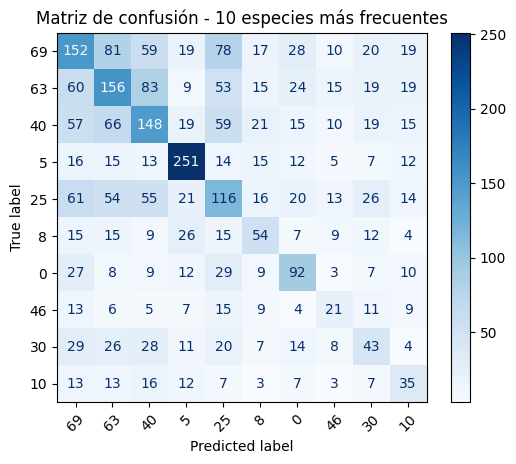

In [34]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()


# Random Forest

Imports

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from io import StringIO
from sklearn.tree import export_graphviz
from sklearn import metrics
from IPython.display import Image
import graphviz
from sklearn.tree import export_graphviz
import pydotplus
import re
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

Eliminación de columnas y división de datos

In [36]:
dfRf = df.copy()

x = dfRf.drop('species', axis=1)
y = dfRf['species']
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42)

Construimos y entrenamos un randomForest con los parametros por defecto

In [37]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(xTrain, yTrain)

yPred = rf.predict(xTest)

print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Accuracy: 0.14106071302506176
Precision: 0.13951391602724464
F1 Score (macro avg): 0.13003537252796132


Evaluamos la importancia de cada feature


In [38]:
importances = rf.feature_importances_
feature_names = xTrain.columns # If X_train is a pandas DataFrame

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)

                          feature  importance
7                            hour    0.171469
8                      hour_cycle    0.169716
1                 decimalLatitude    0.118071
2                decimalLongitude    0.116809
3   coordinateUncertaintyInMeters    0.074003
10                    day_of_year    0.069845
4                             day    0.062276
13               precip_annual_mm    0.053240
12                  temp_annual_c    0.052812
11                    elevation_m    0.048565
5                           month    0.034666
6                       timeRange    0.020594
9                   provincia_num    0.007764
0                 individualCount    0.000170


Dado que existen muchas especies, vamos a evaluar también la precisión de las 3
especies con mayor probabilidad para cada registro de test. Esta métrica brinda información adicional sobre la capacidad predictiva del modelo.

In [39]:
probabilidad = rf.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = rf.classes_[top_3_species_indices]
top_10_species_names = rf.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.14106071302506176
Top-3:  0.27466466643134485
Top-10:  0.486277797387928


In [40]:
# Imprimir las 3 especies con mayor probabilidad y sus probabilidades para cada registro de test
for i in range(10):
    print(f"\nRegistro de test {i+1}:")
    print(yTest.values[i])
    for j in range(3):
        print(f" Especie: {top_3_species_names[i][j]}, Probabilidad: {top_3_probabilities[i][j]:.4f}")


Registro de test 1:
69
 Especie: 60, Probabilidad: 0.2100
 Especie: 5, Probabilidad: 0.1900
 Especie: 0, Probabilidad: 0.1800

Registro de test 2:
69
 Especie: 40, Probabilidad: 0.6300
 Especie: 69, Probabilidad: 0.2200
 Especie: 63, Probabilidad: 0.0300

Registro de test 3:
2
 Especie: 45, Probabilidad: 0.6900
 Especie: 40, Probabilidad: 0.2100
 Especie: 63, Probabilidad: 0.0465

Registro de test 4:
54
 Especie: 64, Probabilidad: 0.3600
 Especie: 54, Probabilidad: 0.2400
 Especie: 30, Probabilidad: 0.1700

Registro de test 5:
70
 Especie: 70, Probabilidad: 0.3000
 Especie: 32, Probabilidad: 0.2400
 Especie: 17, Probabilidad: 0.1400

Registro de test 6:
61
 Especie: 61, Probabilidad: 0.2400
 Especie: 29, Probabilidad: 0.1300
 Especie: 71, Probabilidad: 0.0900

Registro de test 7:
44
 Especie: 11, Probabilidad: 0.4300
 Especie: 5, Probabilidad: 0.1200
 Especie: 44, Probabilidad: 0.0800

Registro de test 8:
5
 Especie: 5, Probabilidad: 0.1800
 Especie: 26, Probabilidad: 0.1700
 Especie:

## Matriz de confusión

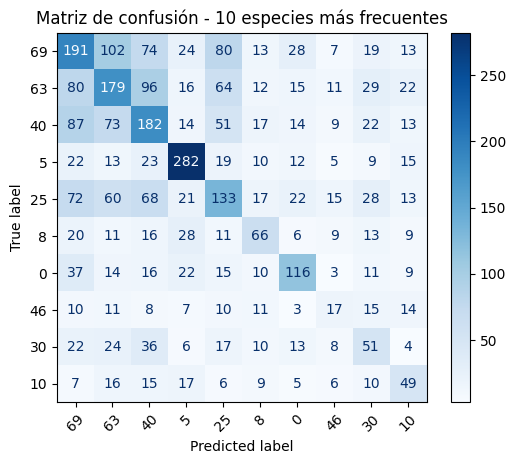

In [41]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()

Reporte de métricas

In [42]:
print(metrics.classification_report(yTest, yPred, digits=4))

              precision    recall  f1-score   support

           0     0.2527    0.2407    0.2465       482
           1     0.0622    0.0644    0.0633       233
           2     0.0773    0.0993    0.0870       141
           3     0.1160    0.1303    0.1227       261
           4     0.1008    0.1282    0.1129       195
           5     0.2693    0.2913    0.2799       968
           6     0.0618    0.0485    0.0543       227
           7     0.0739    0.0667    0.0701       195
           8     0.1312    0.1287    0.1299       513
           9     0.2747    0.2530    0.2634       253
          10     0.1082    0.1101    0.1091       445
          11     0.2403    0.2286    0.2343       245
          12     0.1324    0.1404    0.1363       399
          13     0.1005    0.1266    0.1120       158
          14     0.1094    0.1066    0.1080       197
          15     0.0556    0.0474    0.0512       253
          16     0.1555    0.1713    0.1630       216
          17     0.0755    

# XGBoost

Imports

In [43]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

Eliminación de columnas y división de datos

In [44]:
dfXG = df.copy()

x = dfXG.drop('species',axis=1)
y = dfXG['species']

# 2. Split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42, stratify=y)

Creamos y entrenamos el modelo

In [45]:
# Initialize and train the XGBoost Classifier
# We use XGBClassifier for classification problems.
# 'objective' specifies the loss function for binary classification.
# 'n_estimators' is the number of boosting rounds (trees).
# 'learning_rate' controls the step size shrinkage.

xgbst = xgb.XGBClassifier(objective='multi:softmax',
                          num_class=len(le.classes_), # Specify the number of classes
                          n_estimators=100,
                          learning_rate=0.1,
                          random_state=42)

xgbst.fit(xTrain, yTrain)

# Make predictions on the test set
yPred = xgbst.predict(xTest)

# Evaluate the model's performance
print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Accuracy: 0.1363395693611013
Precision: 0.12645052510532828
F1 Score (macro avg): 0.10767312427356586


In [46]:
probabilidad = xgbst.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = xgbst.classes_[top_3_species_indices]
top_10_species_names = xgbst.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.1363395693611013
Top-3:  0.2747087892693258
Top-10:  0.5283268619837628


## Matriz de confusión

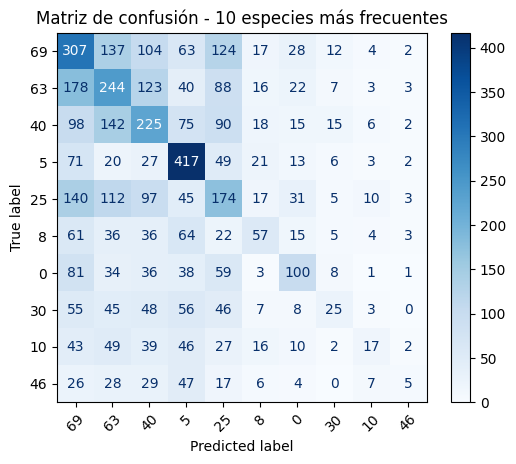

In [47]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
yTest = pd.Series(yTest)
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()